# Random Forest Exploration Notebook

Prototyping Random Forest before moving to production.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

import sys
import os
sys.path.append('../src')
from etl.features import build_features, split_features_targets
from models.poisson import fit_poisson_model, predict_match, evaluate_poisson_model


In [ ]:
data_path = '../../processed/matches_with_features.csv'

if os.path.exists(data_path):
    data = pd.read_csv(data_path)
    print(f"Loaded data from {data_path}")
else:
    print(f"File not found: {data_path}")
    print("Generating synthetic data for testing...")
    
    np.random.seed(42)
    n_samples = 1000
    
    data = pd.DataFrame({
        'match_datetime': pd.date_range('2023-01-01', periods=n_samples, freq='D'),
        'home_team': np.random.choice(['TeamA', 'TeamB', 'TeamC', 'TeamD', 'TeamE'], n_samples),
        'away_team': np.random.choice(['TeamA', 'TeamB', 'TeamC', 'TeamD', 'TeamE'], n_samples),
        'home_goals': np.random.poisson(1.5, n_samples),
        'away_goals': np.random.poisson(1.2, n_samples),
        'result': np.random.choice(['H', 'D', 'A'], n_samples, p=[0.45, 0.25, 0.3]),
        'season': np.random.choice(['2023/2024', '2025/2026'], n_samples),
        'elo_diff': np.random.normal(0, 50, n_samples),
        'home_rolling_goals': np.random.uniform(0.5, 2.5, n_samples),
        'away_rolling_goals': np.random.uniform(0.5, 2.5, n_samples),
        'home_rolling_shots': np.random.uniform(10, 20, n_samples),
        'away_rolling_shots': np.random.uniform(10, 20, n_samples),
    })
    
    print(f"Generated {n_samples} synthetic samples")

print(f"Data shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nFirst few rows:")
print(data.head())

if 'result' in data.columns:
    print(f"\nResult distribution:")
    print(data['result'].value_counts())
else:
    print("\nWarning: 'result' column not found in data")

File not found: ../../processed/matches_with_features.csv
Generating synthetic data for testing...
Generated 1000 synthetic samples
Data shape: (1000, 12)

Columns: ['match_datetime', 'home_team', 'away_team', 'home_goals', 'away_goals', 'result', 'season', 'elo_diff', 'home_rolling_goals', 'away_rolling_goals', 'home_rolling_shots', 'away_rolling_shots']

First few rows:
  match_datetime home_team away_team  home_goals  away_goals result  \
0     2023-01-01     TeamD     TeamD           2           1      A   
1     2023-01-02     TeamE     TeamD           2           2      H   
2     2023-01-03     TeamC     TeamD           1           1      A   
3     2023-01-04     TeamE     TeamD           2           0      A   
4     2023-01-05     TeamE     TeamE           3           0      D   

      season   elo_diff  home_rolling_goals  away_rolling_goals  \
0  2025/2026 -10.159037            1.233916            1.958067   
1  2023/2024 -38.615892            0.667796            2.355620 

In [ ]:
print(data.isna().sum())
print(data.describe())
print(data['result'].value_counts())

match_datetime        0
home_team             0
away_team             0
home_goals            0
away_goals            0
result                0
season                0
elo_diff              0
home_rolling_goals    0
away_rolling_goals    0
home_rolling_shots    0
away_rolling_shots    0
dtype: int64
            match_datetime   home_goals   away_goals     elo_diff  \
count                 1000  1000.000000  1000.000000  1000.000000   
mean   2024-05-14 12:00:00     1.512000     1.171000    -2.344426   
min    2023-01-01 00:00:00     0.000000     0.000000  -167.377530   
25%    2023-09-07 18:00:00     1.000000     0.000000   -36.385770   
50%    2024-05-14 12:00:00     1.000000     1.000000    -2.338971   
75%    2025-01-19 06:00:00     2.000000     2.000000    33.049742   
max    2025-09-26 00:00:00     7.000000     5.000000   148.952748   
std                    NaN     1.244751     1.032873    51.729212   

       home_rolling_goals  away_rolling_goals  home_rolling_shots  \
count   

In [ ]:
if "season" in data.columns:
    train = data[data['season'] != '2025/2026']
    test = data[data['season'] == '2025/2026']
elif "match_datetime" in data.columns:
    train = data[data['match_datetime'] < '2025-08-01 00:00:00']
    test = data[data['match_datetime'] >=  '2025-08-01 00:00:00']
else:
    train, test = train_test_split(data, test_size = 0.2, random_state = 42)

print(train.shape)
print(test.shape)
train.head()
test.head()

(X_train, y_train) = split_features_targets(train)
(X_test, y_test) = split_features_targets(test)

(527, 12)
(473, 12)


In [ ]:
rf_model = RandomForestClassifier(n_estimators = 100, max_depth = None, min_samples_split = 2, class_weight = 'balanced', random_state = 42)
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

print(label_encoder.classes_)

Test accuracy: 0.3594080338266385
              precision    recall  f1-score   support

           0       0.35      0.38      0.36       141
           1       0.22      0.20      0.21       121
           2       0.44      0.44      0.44       211

    accuracy                           0.36       473
   macro avg       0.34      0.34      0.34       473
weighted avg       0.36      0.36      0.36       473

[[53 26 62]
 [41 24 56]
 [59 59 93]]
['A' 'D' 'H']


In [ ]:
y_proba = rf_model.predict_proba(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Home Win', 'Draw', 'Away Win']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

[0.20171541 0.20691454 0.19275026 0.20991001 0.18870978]
              Feature  Importance
3  home_rolling_shots    0.209910
1  home_rolling_goals    0.206915
0            elo_diff    0.201715
2  away_rolling_goals    0.192750
4  away_rolling_shots    0.188710


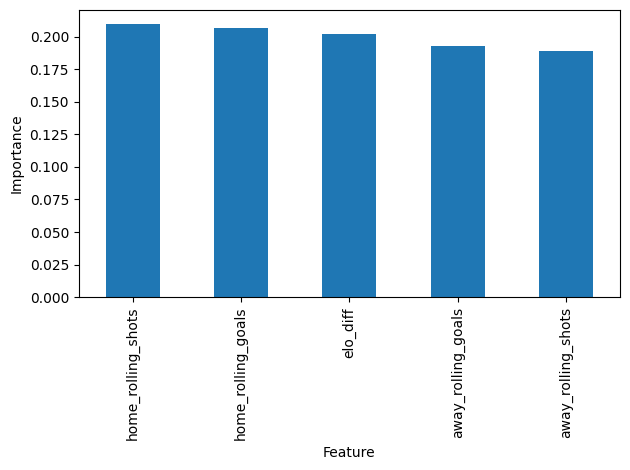

In [ ]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)
print("Top 10 features:")
print(feature_importance.head(10))

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(rf_model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")

Prediction: [0]
Probabilities: [[0.38 0.27 0.35]]
Classes: [0 1 2]


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Test single prediction
sample_idx = 0
feature_row = X_test.iloc[[sample_idx]]
actual_result = label_encoder.inverse_transform([y_test[sample_idx]])[0]
prediction = rf_model.predict(feature_row)[0]
prediction_label = label_encoder.inverse_transform([prediction])[0]
probabilities = rf_model.predict_proba(feature_row)[0]

print(f"Actual: {actual_result}")
print(f"Predicted: {prediction_label}")
print(f"Probabilities: Home={probabilities[0]:.3f}, Draw={probabilities[1]:.3f}, Away={probabilities[2]:.3f}")

In [ ]:
print("=== RANDOM FOREST EXPLORATION SUMMARY ===")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Top 5 features:")
for idx, row in feature_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")